## Datasets preparation

In this notebook we will take the files as they are in the original datasets and we will copy them to the folder structure that we will use for the WMH problem.

The folder structure to follow for the WMH problem will be the WMH dataset one:
~/Code/datasets/wmh/training/
├── Center
&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;├── subj-number
&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;├── pre
&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;├── FLAIR.nii.gz
&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;└── T1.nii.gz
&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;│&nbsp;&nbsp;&nbsp;&nbsp;└── wmh.nii.gz

The same structure is used for the testing set, but without the wmh.nii.gz file (the ground truth).


### 3DMRMS

Access to the dataset: [https://lit.fe.uni-lj.si/en/research/resources/3D-MR-MS/](https://lit.fe.uni-lj.si/en/research/resources/3D-MR-MS/)

In the following code cell, we will take the whole dataset and copy it to the training folder of the WMH dataset.

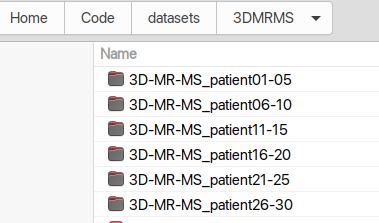

(original folder structure)

In [1]:
import shutil
import os

src_folder = '/home/fmatzkin/Code/datasets/3DMRMS'
dst_folder = '/home/fmatzkin/fast_dataset_cache/wmh_UtrechtSpace/wmh/training/UMCL'

for i in [1, 6, 11, 16, 21, 26]:
    group_path = os.path.join(src_folder, f'3D-MR-MS_patient{i:02}-{i + 4:02}')
    patients = [p for p in os.listdir(group_path) if os.path.isdir(os.path.join(group_path, p))]
    for patient in patients:
        patient_path = os.path.join(group_path, patient)
        patient_no = patient[-2:]
        
        t1_path = os.path.join(patient_path, f'{patient}_T1W.nii.gz')
        flair_path = os.path.join(patient_path, f'{patient}_FLAIR.nii.gz')
        wmh = os.path.join(patient_path, f'{patient}_consensus_gt.nii.gz')
        
        new_t1 = os.path.join(dst_folder, patient_no, 'pre', 'T1.nii.gz')
        new_flair = os.path.join(dst_folder, patient_no, 'pre', 'FLAIR.nii.gz')
        new_wmh = os.path.join(dst_folder, patient_no, 'wmh.nii.gz')
        
        # os.makedirs(os.path.dirname(new_t1), exist_ok=True)
        # shutil.copy(t1_path, new_t1)
        # 
        # os.makedirs(os.path.dirname(new_flair), exist_ok=True)
        # shutil.copy(flair_path, new_flair)
        
        os.makedirs(os.path.dirname(new_wmh), exist_ok=True)
        shutil.copy(wmh, new_wmh)
        
        print(f'Copied {patient_no}')

Copied 04
Copied 05
Copied 02
Copied 01
Copied 03
Copied 10
Copied 09
Copied 06
Copied 07
Copied 08
Copied 15
Copied 11
Copied 12
Copied 13
Copied 14
Copied 16
Copied 20
Copied 18
Copied 17
Copied 19
Copied 24
Copied 22
Copied 21
Copied 23
Copied 25
Copied 26
Copied 30
Copied 28
Copied 27
Copied 29


### MSSEG-1
TODO: Preprocessing?

In [ ]:
import shutil
import os

src_folder = '/home/fmatzkin/Code/datasets/MSSEG-1'
dst_folder = '/home/fmatzkin/Code/datasets/wmh'

centers = {
    'Center_01': 'Rennes',
    'Center_03': 'Bordeaux',
    'Center_07': 'Lyon1',  # 1.5T
    'Center_08': 'Lyon2',  # 3T
}

for split in ['Training', 'Testing']:
    split_path = os.path.join(src_folder, f'MSSEG-{split}', split)
    centers_f = [f for f in os.listdir(split_path) 
                 if os.path.isdir(os.path.join(split_path, f))]
    for center in centers_f:
        new_center = centers[center]
        for patient in os.listdir(os.path.join(split_path, center)):
            patient_path = os.path.join(split_path, center, patient)
            patient_no = patient[-2:]
    
            t1_path = os.path.join(patient_path, f'{patient}_T1W.nii.gz')
            flair_path = os.path.join(patient_path, f'{patient}_FLAIR.nii.gz')
            wmh = os.path.join(patient_path, f'{patient}_consensus_gt.nii.gz')
    
            new_t1 = os.path.join(dst_folder, patient_no, 'pre', 'T1.nii.gz')
            new_flair = os.path.join(dst_folder, patient_no, 'pre', 'FLAIR.nii.gz')
            new_wmh = os.path.join(dst_folder, patient_no, 'wmh.nii.gz')
    
            os.makedirs(os.path.dirname(new_t1), exist_ok=True)
            shutil.copy(t1_path, new_t1)
    
            os.makedirs(os.path.dirname(new_flair), exist_ok=True)
            shutil.copy(flair_path, new_flair)
    
            os.makedirs(os.path.dirname(new_wmh), exist_ok=True)
            shutil.copy(wmh, new_wmh)
    
            print(f'Copied {patient_no}')

### ISBI15